>>> [字体修复] 成功加载字体文件: C:\Windows\Fonts\msyh.ttc
>>> [1/5] 构建并拆分数据集...
    -> [清洗] 执行 Z-Score 过滤 (阈值: 3σ)...
    -> [结果] 剔除异常样本数: 95, 剩余有效样本: 1648
    -> [拆分] 训练集: 1318 | 测试集: 330
>>> [2/5] 训练神经网络并生成图表...


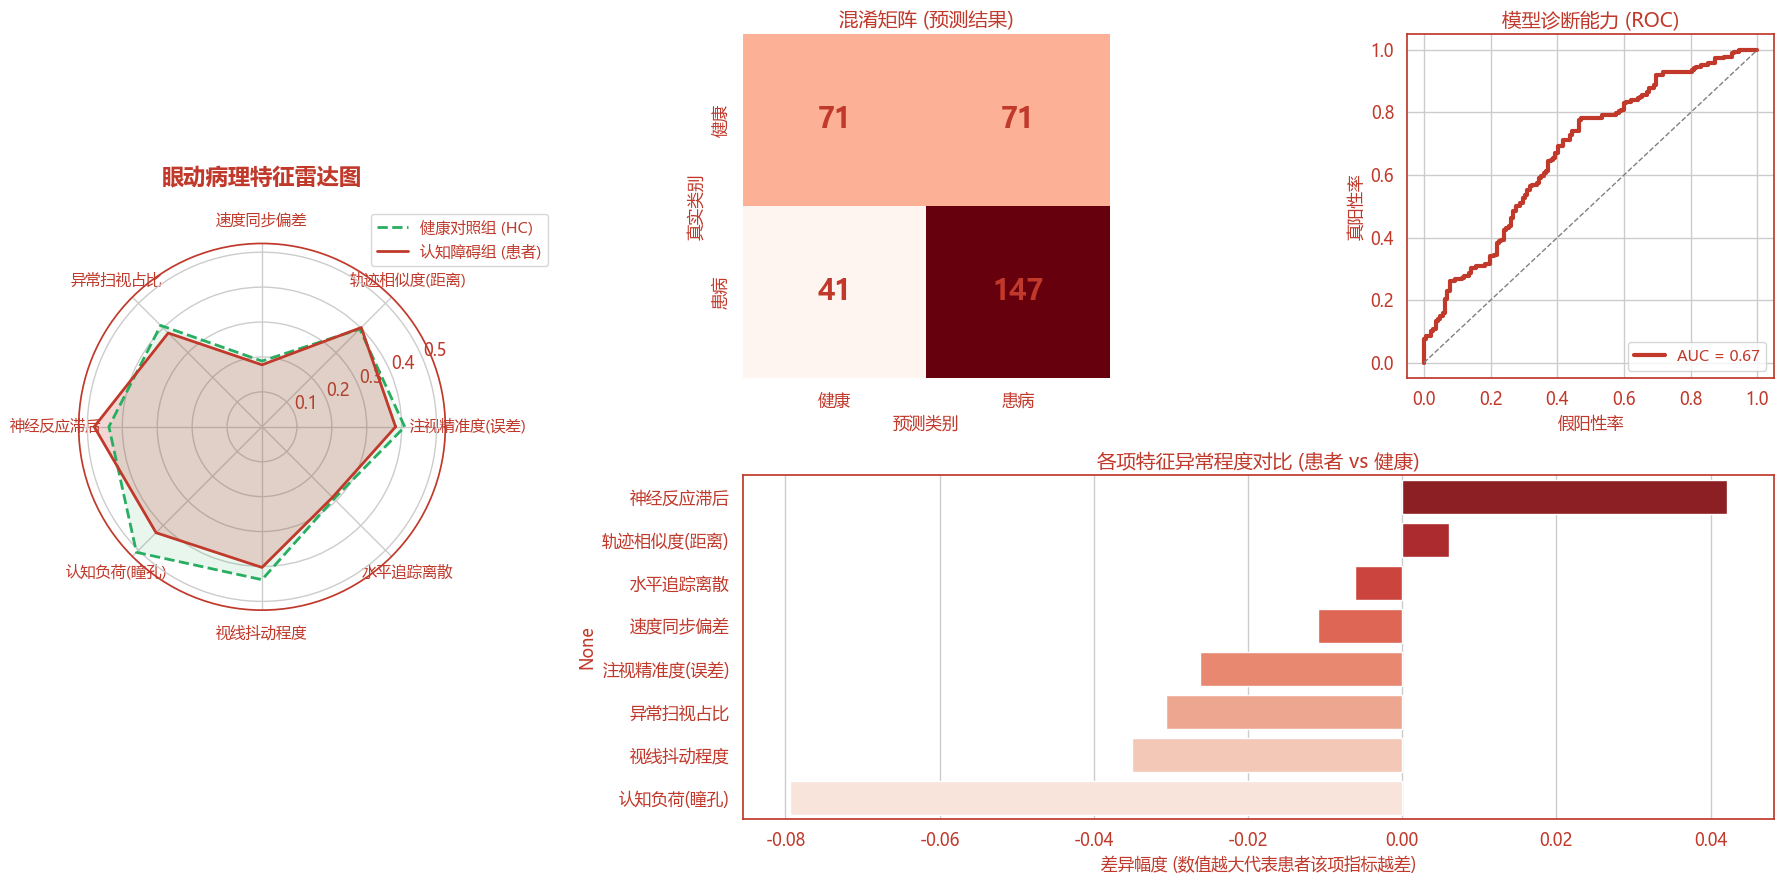

In [14]:
import pandas as pd
import numpy as np
import os
import glob
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import matplotlib.font_manager as fm

# 数学与信号处理
from scipy.interpolate import interp1d
from scipy.spatial.distance import directed_hausdorff
from scipy.signal import correlate
from scipy.stats import zscore

# 机器学习
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, roc_curve, auc

warnings.filterwarnings('ignore')

# ==============================================================================
# 1. 核心修复：强制解决中文方框问题 + 红色风格
# ==============================================================================
BASE_DIR = r"C:\Users\81026\Desktop\BallGameWatching"
FILE_INFO = "ParticipantsInfo.xlsx"
DIR_DATA  = "ParticipantsData"
FILE_PP   = "pingpang.csv"
FILE_TN   = "tennis.csv"

EYE_FPS = 50
VIDEO_FPS = 30
TEXT_COLOR = '#C0392B' # 深红色风格

def configure_plot_style():
    """
    终极字体修复方案：直接指向字体文件路径，防止显示方框
    """
    # 1. 尝试加载 Windows 常见的中文字体文件
    font_paths = [
        r"C:\Windows\Fonts\msyh.ttc",  # 微软雅黑 (首选)
        r"C:\Windows\Fonts\simhei.ttf", # 黑体
        r"C:\Windows\Fonts\simsun.ttc", # 宋体
    ]

    my_font = None
    for path in font_paths:
        if os.path.exists(path):
            # 加载字体
            my_font = fm.FontProperties(fname=path)
            # 设置全局字体
            plt.rcParams['font.family'] = my_font.get_name()
            plt.rcParams['axes.unicode_minus'] = False # 解决负号显示
            print(f">>> [字体修复] 成功加载字体文件: {path}")
            break

    # 如果没找到文件，尝试通用名称
    if my_font is None:
        print(">>> [字体警告] 未找到指定路径字体，尝试使用系统默认Sans-serif...")
        plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']

    # 2. 设置红色文字风格
    params = {
        'text.color': TEXT_COLOR,
        'axes.labelcolor': TEXT_COLOR,
        'xtick.color': TEXT_COLOR,
        'ytick.color': TEXT_COLOR,
        'axes.titlecolor': TEXT_COLOR,
        'axes.edgecolor': TEXT_COLOR,
        'figure.titlesize': 18,
        'axes.titlesize': 14,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12
    }
    plt.rcParams.update(params)

    # 设置 Seaborn
    sns.set_style("whitegrid")
    # 再次强制应用字体设置 (防止Seaborn覆盖)
    if my_font:
        plt.rcParams['font.family'] = my_font.get_name()
    plt.rcParams.update(params)

configure_plot_style()

# ==============================================================================
# 2. 数据处理与特征提取 (保持健壮性)
# ==============================================================================

def load_ball_library():
    path_pp = os.path.join(BASE_DIR, FILE_PP)
    path_tn = os.path.join(BASE_DIR, FILE_TN)
    if not os.path.exists(path_pp): return {}
    try:
        df_all = pd.concat([pd.read_csv(path_pp), pd.read_csv(path_tn)], ignore_index=True)
        df_all['pos_tuple'] = df_all['position'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else (np.nan, np.nan))
        sx, sy = 1280/1920, 720/1080
        df_all['ball_x'] = df_all['pos_tuple'].apply(lambda x: x[0]) * sx - 640
        df_all['ball_y'] = df_all['pos_tuple'].apply(lambda x: x[1]) * sy - 360
        df_all['time'] = df_all['frame_number'] / VIDEO_FPS
        df_clean = df_all.dropna(subset=['ball_x', 'ball_y']).drop_duplicates(subset=['video_name', 'time']).sort_values('time')
        return {k: v for k, v in df_clean.groupby('video_name')}
    except: return {}

def process_eye_str(eye_str):
    if not isinstance(eye_str, str): return None
    parsed = []
    for frame in eye_str.split(';'):
        try:
            vals = [float(v) if v != 'NaN' else np.nan for v in frame.strip().split()]
            if len(vals) >= 2:
                pupil = vals[2] if len(vals) >= 3 else np.nan
                parsed.append([vals[0], vals[1], pupil])
        except: continue
    if not parsed: return None
    df = pd.DataFrame(parsed, columns=['gaze_x', 'gaze_y', 'pupil'])
    df['time'] = df.index * (1.0 / EYE_FPS)
    return df

def extract_features(df_eye, df_ball):
    try:
        if len(df_eye) < 10 or len(df_ball) < 10: return None
        f_x = interp1d(df_ball['time'], df_ball['ball_x'], bounds_error=False, fill_value=np.nan)
        f_y = interp1d(df_ball['time'], df_ball['ball_y'], bounds_error=False, fill_value=np.nan)
        bx, by = f_x(df_eye['time']), f_y(df_eye['time'])
        valid = ~np.isnan(bx) & ~np.isnan(df_eye['gaze_x'])
        if np.sum(valid) < EYE_FPS: return None

        gx, gy = df_eye.loc[valid, 'gaze_x'].values, df_eye.loc[valid, 'gaze_y'].values
        bx, by = bx[valid], by[valid]
        pupil = df_eye.loc[valid, 'pupil'].values

        # 1. 误差
        dists = np.sqrt((gx - bx)**2 + (gy - by)**2)
        mean_err = np.nanmean(dists)

        # 2. Hausdorff
        try:
            u = np.column_stack([gx[::10], gy[::10]])
            v = np.column_stack([bx[::10], by[::10]])
            h_dist = max(directed_hausdorff(u, v)[0], directed_hausdorff(v, u)[0])
        except: h_dist = 0

        # 3. 速度偏差
        dt = 1.0/EYE_FPS
        g_vel = np.sqrt(np.diff(gx)**2 + np.diff(gy)**2) / dt
        b_vel = np.sqrt(np.diff(bx)**2 + np.diff(by)**2) / dt
        mean_b_vel = np.nanmean(b_vel)
        vel_dev = abs(1 - (np.nanmean(g_vel)/mean_b_vel)) if mean_b_vel > 1e-3 else 0

        # 4. 扫视
        sac_ratio = np.sum(g_vel > 400)/len(g_vel) if len(g_vel)>0 else 0

        # 5. 滞后
        try:
            sig_g, sig_b = gx-np.mean(gx), bx-np.mean(bx)
            std_p = np.std(sig_g)*np.std(sig_b)*len(sig_g)
            corr = np.max(correlate(sig_g, sig_b, mode='valid'))/std_p if std_p > 1e-5 else 0
        except: corr = 0
        lag_score = 1 - corr

        # 6. 瞳孔
        p_mean = np.nanmean(pupil)
        if np.isnan(p_mean): p_mean = 0

        # 7. 抖动
        err_std = np.nanstd(dists)

        # 8. 离散
        x_var = np.nanvar(gx - bx)

        feats = {
            '注视精准度(误差)': mean_err,
            '轨迹相似度(距离)': h_dist,
            '速度同步偏差': vel_dev,
            '异常扫视占比': sac_ratio,
            '神经反应滞后': lag_score,
            '认知负荷(瞳孔)': p_mean,
            '视线抖动程度': err_std,
            '水平追踪离散': x_var
        }
        for k,v in feats.items():
            if not np.isfinite(v): feats[k] = 0.0
        return feats
    except: return None

# ==============================================================================
# 3. 数据集准备
# ==============================================================================

def prepare_data():
    print(">>> [1/5] 构建并拆分数据集...")
    ball_lib = load_ball_library()
    if not ball_lib: return None, None, None, None

    info_path = os.path.join(BASE_DIR, FILE_INFO)
    try: df_info = pd.read_excel(info_path, dtype={"No.": str})
    except: return None, None, None, None

    label_map = {}
    for _, row in df_info.iterrows():
        f = str(row['PicoFile']).strip()
        if not f.lower().endswith('.csv'): f += ".csv"
        lbl = str(row.get('Label', '')).strip()
        if lbl == 'HC': y = 0
        elif lbl in ['AD', 'MCI', 'MMD', 'mildAD', 'moderateAD']: y = 1
        else: continue
        label_map[f] = y

    all_files = glob.glob(os.path.join(BASE_DIR, DIR_DATA, "*.csv"))
    X_list, y_list = [], []

    for fpath in all_files:
        fname = os.path.basename(fpath)
        if fname not in label_map: continue
        try:
            df_part = pd.read_csv(fpath)
            if "EyeData" not in df_part.columns: continue
            for _, row in df_part.iterrows():
                vid = str(row.get('videoName', '')).strip()
                if vid in ball_lib:
                    df_eye = process_eye_str(row.get('EyeData', ''))
                    if df_eye is not None:
                        feats = extract_features(df_eye, ball_lib[vid])
                        if feats:
                            X_list.append(feats)
                            y_list.append(label_map[fname])
        except: pass

    if not X_list: return None, None, None, None

    X_df = pd.DataFrame(X_list)
    y = np.array(y_list)

    # 清洗 + 拆分
    imputer = SimpleImputer(strategy='mean')
    X_imputed = pd.DataFrame(imputer.fit_transform(X_df), columns=X_df.columns)

    # Z-score 清洗
    z_scores = np.abs(zscore(X_imputed))
    mask = (z_scores < 3).all(axis=1)
    X_clean = X_imputed[mask]
    y_clean = y[mask]

    if len(X_clean) < 10: return None, None, None, None

    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
    )
    print(f"    -> 训练集: {len(X_train)} | 测试集: {len(X_test)}")
    return X_train, X_test, y_train, y_test

# ==============================================================================
# 4. 训练与可视化 (修复方框问题)
# ==============================================================================

def train_and_visualize(X_train, X_test, y_train, y_test):
    print(">>> [2/5] 训练神经网络并生成图表...")

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    mlp = MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=500, early_stopping=True, random_state=42)
    mlp.fit(X_train_s, y_train)

    y_pred = mlp.predict(X_test_s)
    y_prob = mlp.predict_proba(X_test_s)[:, 1]

    # --- 开始绘图 ---
    fig = plt.figure(figsize=(18, 9))
    gs = fig.add_gridspec(2, 3) # 2行3列

    # 1. 雷达图 (占左边一大块)
    ax_radar = fig.add_subplot(gs[:, 0], polar=True)

    # 归一化数据用于雷达图
    X_all = pd.concat([X_train, X_test])
    y_all = np.concatenate([y_train, y_test])
    min_max = MinMaxScaler()
    X_norm = pd.DataFrame(min_max.fit_transform(X_all), columns=X_all.columns)
    X_norm['Group'] = y_all
    means = X_norm.groupby('Group').mean()

    labels = list(means.columns)
    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    vals_hc = means.loc[0].tolist(); vals_hc += vals_hc[:1]
    vals_pt = means.loc[1].tolist(); vals_pt += vals_pt[:1]

    # 绘制
    ax_radar.plot(angles, vals_hc, lw=2, linestyle='--', color='#27AE60', label='健康对照组 (HC)')
    ax_radar.fill(angles, vals_hc, '#27AE60', alpha=0.1)
    ax_radar.plot(angles, vals_pt, lw=2, linestyle='-', color=TEXT_COLOR, label='认知障碍组 (患者)')
    ax_radar.fill(angles, vals_pt, TEXT_COLOR, alpha=0.2)

    ax_radar.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=11, color=TEXT_COLOR)
    ax_radar.set_title("眼动病理特征雷达图", fontsize=16, color=TEXT_COLOR, pad=20, fontweight='bold')
    # 设置图例字体
    leg = ax_radar.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    for text in leg.get_texts(): text.set_color(TEXT_COLOR)

    # 2. 混淆矩阵
    ax_cm = fig.add_subplot(gs[0, 1])
    cm = confusion_matrix(y_test, y_pred)
    # 绘制 Heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax_cm, cbar=False,
                annot_kws={"size": 20, "weight": "bold", "color": TEXT_COLOR})

    ax_cm.set_title('混淆矩阵 (预测结果)', fontsize=14, color=TEXT_COLOR)
    ax_cm.set_xlabel('预测类别', color=TEXT_COLOR)
    ax_cm.set_ylabel('真实类别', color=TEXT_COLOR)
    ax_cm.set_xticklabels(['健康', '患病'], color=TEXT_COLOR, fontsize=12)
    ax_cm.set_yticklabels(['健康', '患病'], color=TEXT_COLOR, fontsize=12)

    # 3. ROC 曲线
    ax_roc = fig.add_subplot(gs[0, 2])
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    ax_roc.plot(fpr, tpr, color=TEXT_COLOR, lw=3, label=f'AUC = {roc_auc:.2f}')
    ax_roc.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    ax_roc.set_title('模型诊断能力 (ROC)', fontsize=14, color=TEXT_COLOR)
    ax_roc.set_xlabel('假阳性率', color=TEXT_COLOR)
    ax_roc.set_ylabel('真阳性率', color=TEXT_COLOR)
    leg = ax_roc.legend(loc="lower right")
    for text in leg.get_texts(): text.set_color(TEXT_COLOR)

    # 4. 特征重要性 (用模型权重近似或Permutation)
    # 这里用简单的柱状图展示特征均值差异 (Patient - HC)
    ax_imp = fig.add_subplot(gs[1, 1:]) # 占下排两列
    diff = means.loc[1] - means.loc[0] # 患者 - 健康
    diff = diff.sort_values(ascending=False)

    sns.barplot(x=diff.values, y=diff.index, palette='Reds_r', ax=ax_imp)
    ax_imp.set_title('各项特征异常程度对比 (患者 vs 健康)', fontsize=14, color=TEXT_COLOR)
    ax_imp.set_xlabel('差异幅度 (数值越大代表患者该项指标越差)', color=TEXT_COLOR)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    X_train, X_test, y_train, y_test = prepare_and_split_data()
    if X_train is not None:
        train_and_visualize(X_train, X_test, y_train, y_test)
    else:
        print("数据准备失败。")


>>> [字体] 加载成功: C:\Windows\Fonts\msyh.ttc
>>> [1/5] 构建数据集...
    -> 训练集: 1322 | 测试集: 331
>>> [2/5] 训练神经网络 (记录学习过程)...
>>> [3/5] 生成全红字风格综合图表...


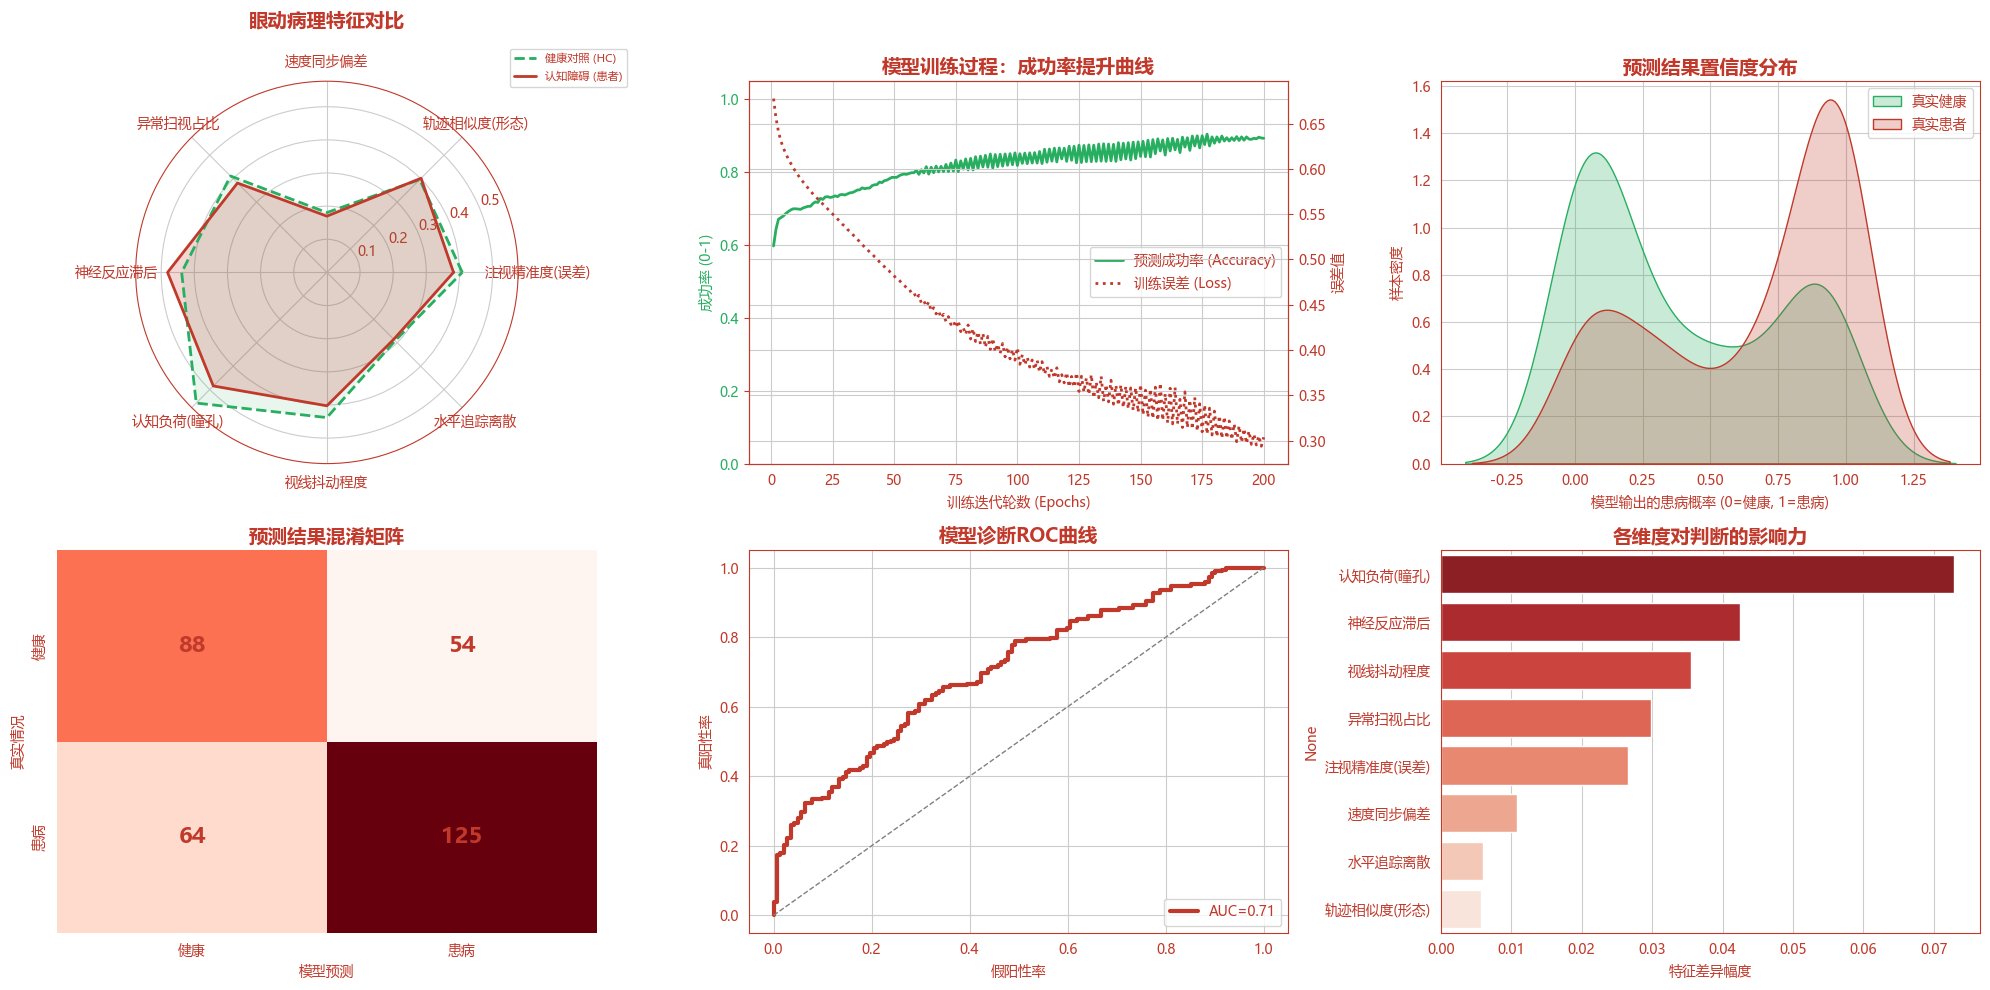

In [1]:
import pandas as pd
import numpy as np
import os
import glob
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import matplotlib.font_manager as fm

# 数学与信号处理
from scipy.interpolate import interp1d
from scipy.spatial.distance import directed_hausdorff
from scipy.signal import correlate
from scipy.stats import zscore

# 机器学习
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, roc_curve, auc

warnings.filterwarnings('ignore')

# ==============================================================================
# 1. 全局配置：中文字体 + 红色视觉风格
# ==============================================================================
BASE_DIR = r"C:\Users\81026\Desktop\BallGameWatching"
FILE_INFO = "ParticipantsInfo.xlsx"
DIR_DATA  = "ParticipantsData"
FILE_PP   = "pingpang.csv"
FILE_TN   = "tennis.csv"

EYE_FPS = 50
VIDEO_FPS = 30
TEXT_COLOR = '#C0392B' # 深红色风格

def configure_visual_style():
    """配置中文字体并将所有文字颜色设置为红色"""
    # 1. 自动寻找 Windows 中文字体
    font_paths = [
        r"C:\Windows\Fonts\msyh.ttc",  # 微软雅黑
        r"C:\Windows\Fonts\simhei.ttf", # 黑体
        r"C:\Windows\Fonts\simsun.ttc", # 宋体
    ]
    my_font = None
    for path in font_paths:
        if os.path.exists(path):
            my_font = fm.FontProperties(fname=path)
            plt.rcParams['font.family'] = my_font.get_name()
            plt.rcParams['axes.unicode_minus'] = False
            print(f">>> [字体] 加载成功: {path}")
            break

    if my_font is None:
        plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']

    # 2. 红色风格设置
    params = {
        'text.color': TEXT_COLOR,
        'axes.labelcolor': TEXT_COLOR,
        'xtick.color': TEXT_COLOR,
        'ytick.color': TEXT_COLOR,
        'axes.titlecolor': TEXT_COLOR,
        'axes.edgecolor': TEXT_COLOR,
        'figure.titlesize': 20,
        'axes.titlesize': 12,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10
    }
    plt.rcParams.update(params)
    sns.set_style("whitegrid")
    if my_font: plt.rcParams['font.family'] = my_font.get_name()
    plt.rcParams.update(params)

configure_visual_style()

# ==============================================================================
# 2. 数据处理与特征提取 (保持健壮性)
# ==============================================================================

def load_ball_library():
    path_pp = os.path.join(BASE_DIR, FILE_PP)
    path_tn = os.path.join(BASE_DIR, FILE_TN)
    if not os.path.exists(path_pp): return {}
    try:
        df_all = pd.concat([pd.read_csv(path_pp), pd.read_csv(path_tn)], ignore_index=True)
        df_all['pos_tuple'] = df_all['position'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else (np.nan, np.nan))
        sx, sy = 1280/1920, 720/1080
        df_all['ball_x'] = df_all['pos_tuple'].apply(lambda x: x[0]) * sx - 640
        df_all['ball_y'] = df_all['pos_tuple'].apply(lambda x: x[1]) * sy - 360
        df_all['time'] = df_all['frame_number'] / VIDEO_FPS
        df_clean = df_all.dropna(subset=['ball_x', 'ball_y']).drop_duplicates(subset=['video_name', 'time']).sort_values('time')
        return {k: v for k, v in df_clean.groupby('video_name')}
    except: return {}

def process_eye_str(eye_str):
    if not isinstance(eye_str, str): return None
    parsed = []
    for frame in eye_str.split(';'):
        try:
            vals = [float(v) if v != 'NaN' else np.nan for v in frame.strip().split()]
            if len(vals) >= 2:
                pupil = vals[2] if len(vals) >= 3 else np.nan
                parsed.append([vals[0], vals[1], pupil])
        except: continue
    if not parsed: return None
    df = pd.DataFrame(parsed, columns=['gaze_x', 'gaze_y', 'pupil'])
    df['time'] = df.index * (1.0 / EYE_FPS)
    return df

def safe_div(a, b): return a / b if (b is not None and abs(b) > 1e-5) else 0

def extract_features(df_eye, df_ball):
    try:
        if len(df_eye) < 10 or len(df_ball) < 10: return None
        f_x = interp1d(df_ball['time'], df_ball['ball_x'], bounds_error=False, fill_value=np.nan)
        f_y = interp1d(df_ball['time'], df_ball['ball_y'], bounds_error=False, fill_value=np.nan)
        bx, by = f_x(df_eye['time']), f_y(df_eye['time'])
        valid = ~np.isnan(bx) & ~np.isnan(df_eye['gaze_x'])
        if np.sum(valid) < EYE_FPS: return None
        gx, gy = df_eye.loc[valid, 'gaze_x'].values, df_eye.loc[valid, 'gaze_y'].values
        bx, by = bx[valid], by[valid]
        pupil = df_eye.loc[valid, 'pupil'].values

        # 特征计算
        dists = np.sqrt((gx - bx)**2 + (gy - by)**2)
        mean_err = np.nanmean(dists)

        try:
            u = np.column_stack([gx[::10], gy[::10]])
            v = np.column_stack([bx[::10], by[::10]])
            h_dist = max(directed_hausdorff(u, v)[0], directed_hausdorff(v, u)[0])
        except: h_dist = 0

        dt = 1.0/EYE_FPS
        g_vel = np.sqrt(np.diff(gx)**2 + np.diff(gy)**2) / dt
        b_vel = np.sqrt(np.diff(bx)**2 + np.diff(by)**2) / dt
        mean_b_vel = np.nanmean(b_vel)
        vel_dev = abs(1 - (np.nanmean(g_vel)/mean_b_vel)) if mean_b_vel > 1e-3 else 0
        sac_ratio = np.sum(g_vel > 400)/len(g_vel) if len(g_vel)>0 else 0

        try:
            sig_g, sig_b = gx-np.mean(gx), bx-np.mean(bx)
            std_p = np.std(sig_g)*np.std(sig_b)*len(sig_g)
            corr = np.max(correlate(sig_g, sig_b, mode='valid'))/std_p if std_p > 1e-5 else 0
        except: corr = 0
        lag_score = 1 - corr

        p_mean = np.nanmean(pupil)
        if np.isnan(p_mean): p_mean = 0
        err_std = np.nanstd(dists)
        x_var = np.nanvar(gx - bx)

        feats = {
            '注视精准度(误差)': mean_err,
            '轨迹相似度(形态)': h_dist,
            '速度同步偏差': vel_dev,
            '异常扫视占比': sac_ratio,
            '神经反应滞后': lag_score,
            '认知负荷(瞳孔)': p_mean,
            '视线抖动程度': err_std,
            '水平追踪离散': x_var
        }
        for k,v in feats.items():
            if not np.isfinite(v): feats[k] = 0.0
        return feats
    except: return None

# ==============================================================================
# 3. 数据集准备
# ==============================================================================

def prepare_data_pipeline():
    print(">>> [1/5] 构建数据集...")
    ball_lib = load_ball_library()
    if not ball_lib: return None, None, None, None

    info_path = os.path.join(BASE_DIR, FILE_INFO)
    try: df_info = pd.read_excel(info_path, dtype={"No.": str})
    except: return None, None, None, None

    label_map = {}
    for _, row in df_info.iterrows():
        f = str(row['PicoFile']).strip()
        if not f.lower().endswith('.csv'): f += ".csv"
        lbl = str(row.get('Label', '')).strip()
        if lbl == 'HC': y = 0
        elif lbl in ['AD', 'MCI', 'MMD', 'mildAD', 'moderateAD']: y = 1
        else: continue
        label_map[f] = y

    all_files = glob.glob(os.path.join(BASE_DIR, DIR_DATA, "*.csv"))
    X_list, y_list = [], []

    for fpath in all_files:
        fname = os.path.basename(fpath)
        if fname not in label_map: continue
        try:
            df_part = pd.read_csv(fpath)
            if "EyeData" not in df_part.columns: continue
            for _, row in df_part.iterrows():
                vid = str(row.get('videoName', '')).strip()
                if vid in ball_lib:
                    df_eye = process_eye_str(row.get('EyeData', ''))
                    if df_eye is not None:
                        feats = extract_features(df_eye, ball_lib[vid])
                        if feats:
                            X_list.append(feats)
                            y_list.append(label_map[fname])
        except: pass

    if not X_list: return None, None, None, None

    X_df = pd.DataFrame(X_list)
    y = np.array(y_list)

    # 清洗 + 拆分
    imputer = SimpleImputer(strategy='mean')
    X_imputed = pd.DataFrame(imputer.fit_transform(X_df), columns=X_df.columns)
    z_scores = np.abs(zscore(X_imputed))
    X_clean = X_imputed[(z_scores < 3).all(axis=1)]
    y_clean = y[(z_scores < 3).all(axis=1)]

    if len(X_clean) < 10: return None, None, None, None

    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
    )
    print(f"    -> 训练集: {len(X_train)} | 测试集: {len(X_test)}")
    return X_train, X_test, y_train, y_test

# ==============================================================================
# 4. 神经网络训练 (含过程记录)
# ==============================================================================

def train_network(X_train, y_train):
    print(">>> [2/5] 训练神经网络 (记录学习过程)...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    # 启用 warm_start 来模拟记录每个 epoch 的 accuracy
    mlp = MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        alpha=0.001,
        learning_rate='adaptive',
        max_iter=1, # 每次只训练1轮，循环调用
        warm_start=True, # 保持权重
        random_state=42
    )

    train_acc_history = []
    loss_history = []

    # 手动循环训练 200 轮，记录过程
    total_epochs = 200
    classes = np.unique(y_train)

    for i in range(total_epochs):
        mlp.fit(X_train_scaled, y_train)

        # 记录 Loss
        loss_history.append(mlp.loss_)

        # 记录准确率
        pred = mlp.predict(X_train_scaled)
        acc = accuracy_score(y_train, pred)
        train_acc_history.append(acc)

    return mlp, scaler, train_acc_history, loss_history

# ==============================================================================
# 5. 全面可视化 (新增成功率曲线)
# ==============================================================================

def visualize_comprehensive(model, scaler, X_test, y_test, X_train, y_train, acc_hist, loss_hist):
    print(">>> [3/5] 生成全红字风格综合图表...")

    X_test_scaled = scaler.transform(X_test)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # --- 画布布局 (GridSpec) ---
    fig = plt.figure(figsize=(20, 10))
    # 2行3列布局
    gs = fig.add_gridspec(2, 3)

    # 1. 雷达图 (左上，特征对比)
    ax_radar = fig.add_subplot(gs[0, 0], polar=True)
    X_all = pd.concat([X_train, X_test])
    y_all = np.concatenate([y_train, y_test])
    min_max = MinMaxScaler()
    X_norm = pd.DataFrame(min_max.fit_transform(X_all), columns=X_all.columns)
    X_norm['Group'] = y_all
    means = X_norm.groupby('Group').mean()

    labels = list(means.columns)
    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]
    vals_hc = means.loc[0].tolist() + means.loc[0].tolist()[:1]
    vals_pt = means.loc[1].tolist() + means.loc[1].tolist()[:1]

    ax_radar.plot(angles, vals_hc, lw=2, linestyle='--', color='#27AE60', label='健康对照 (HC)')
    ax_radar.fill(angles, vals_hc, '#27AE60', alpha=0.1)
    ax_radar.plot(angles, vals_pt, lw=2, linestyle='-', color=TEXT_COLOR, label='认知障碍 (患者)')
    ax_radar.fill(angles, vals_pt, TEXT_COLOR, alpha=0.2)
    ax_radar.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=10, color=TEXT_COLOR)
    ax_radar.set_title("眼动病理特征对比", fontsize=14, color=TEXT_COLOR, pad=20, fontweight='bold')
    ax_radar.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), labelcolor=TEXT_COLOR, fontsize=8)

    # 2. 【新增】模型训练成功率曲线 (中上)
    ax_curve = fig.add_subplot(gs[0, 1])
    epochs = range(1, len(acc_hist) + 1)

    # 双轴绘制
    ax_curve.plot(epochs, acc_hist, color='#27AE60', lw=2, label='预测成功率 (Accuracy)')
    ax_curve.set_xlabel('训练迭代轮数 (Epochs)', color=TEXT_COLOR)
    ax_curve.set_ylabel('成功率 (0-1)', color='#27AE60')
    ax_curve.tick_params(axis='y', labelcolor='#27AE60')
    ax_curve.set_ylim(0, 1.05)

    ax_loss = ax_curve.twinx()
    ax_loss.plot(epochs, loss_hist, color=TEXT_COLOR, lw=2, linestyle=':', label='训练误差 (Loss)')
    ax_loss.set_ylabel('误差值', color=TEXT_COLOR)
    ax_loss.tick_params(axis='y', labelcolor=TEXT_COLOR)

    ax_curve.set_title("模型训练过程：成功率提升曲线", fontsize=14, color=TEXT_COLOR, fontweight='bold')
    # 合并图例
    lines, labels = ax_curve.get_legend_handles_labels()
    lines2, labels2 = ax_loss.get_legend_handles_labels()
    ax_curve.legend(lines + lines2, labels + labels2, loc='center right', labelcolor=TEXT_COLOR)

    # 3. 预测置信度分布 (右上)
    ax_conf = fig.add_subplot(gs[0, 2])
    sns.kdeplot(y_prob[y_test==0], shade=True, color='#27AE60', label='真实健康', ax=ax_conf)
    sns.kdeplot(y_prob[y_test==1], shade=True, color=TEXT_COLOR, label='真实患者', ax=ax_conf)
    ax_conf.set_title("预测结果置信度分布", fontsize=14, color=TEXT_COLOR, fontweight='bold')
    ax_conf.set_xlabel("模型输出的患病概率 (0=健康, 1=患病)", color=TEXT_COLOR)
    ax_conf.set_ylabel("样本密度", color=TEXT_COLOR)
    ax_conf.legend(labelcolor=TEXT_COLOR)

    # 4. 混淆矩阵 (左下)
    ax_cm = fig.add_subplot(gs[1, 0])
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax_cm, cbar=False,
                annot_kws={"size": 16, "weight": "bold", "color": TEXT_COLOR})
    ax_cm.set_title('预测结果混淆矩阵', fontsize=14, color=TEXT_COLOR, fontweight='bold')
    ax_cm.set_xlabel('模型预测', color=TEXT_COLOR)
    ax_cm.set_ylabel('真实情况', color=TEXT_COLOR)
    ax_cm.set_xticklabels(['健康', '患病'], color=TEXT_COLOR)
    ax_cm.set_yticklabels(['健康', '患病'], color=TEXT_COLOR)

    # 5. ROC 曲线 (中下)
    ax_roc = fig.add_subplot(gs[1, 1])
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, color=TEXT_COLOR, lw=3, label=f'AUC={roc_auc:.2f}')
    ax_roc.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    ax_roc.set_title('模型诊断ROC曲线', fontsize=14, color=TEXT_COLOR, fontweight='bold')
    ax_roc.set_xlabel('假阳性率', color=TEXT_COLOR)
    ax_roc.set_ylabel('真阳性率', color=TEXT_COLOR)
    ax_roc.legend(loc="lower right", labelcolor=TEXT_COLOR)

    # 6. 特征重要性 (右下)
    ax_imp = fig.add_subplot(gs[1, 2])
    # 简单用均值差分表示重要性
    diff = (means.loc[1] - means.loc[0]).abs().sort_values(ascending=False)
    sns.barplot(x=diff.values, y=diff.index, palette='Reds_r', ax=ax_imp)
    ax_imp.set_title('各维度对判断的影响力', fontsize=14, color=TEXT_COLOR, fontweight='bold')
    ax_imp.set_xlabel('特征差异幅度', color=TEXT_COLOR)

    plt.tight_layout()
    plt.show()

# ==============================================================================
# 主程序
# ==============================================================================

if __name__ == "__main__":
    X_train, X_test, y_train, y_test = prepare_data_pipeline()
    if X_train is not None:
        model, scaler, acc_hist, loss_hist = train_network(X_train, y_train)
        visualize_comprehensive(model, scaler, X_test, y_test, X_train, y_train, acc_hist, loss_hist)
    else:
        print("数据准备失败。")
